In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

# Default: local Ollama gemma3:12b -- the same model used in the published
# rmllm/psychscanner-team experiments (arXiv:2607.23927). No API key, runs
# offline once pulled. Make sure `ollama serve` is running and the model is
# pulled:
#   ollama pull gemma3:12b
MODEL_NAME   = "gemma3:12b"
MODEL_FAMILY = "ollama"

# Alternative: Groq-hosted gpt-oss-120b. Uncomment to use, and make sure
# GROQ_API_KEY is set in your .env. psychscanner loads it automatically.
# MODEL_NAME   = "openai/gpt-oss-120b"
# MODEL_FAMILY = "groq"

from langchain.chat_models import init_chat_model

llm = init_chat_model(model=MODEL_NAME, model_provider=MODEL_FAMILY, temperature=0)
llm.invoke("what's your name")


In [2]:
from langchain_core.messages import HumanMessage
from psychscanner import ExpCard, ExpCardInit, ScannerModel
from psychscanner.parsers import (
    list_parsers,
    get_parser,
    ResponseRmStEI,
    AllResponseRMEI,
)
from psychscanner.datasets.prompts.parser_tasks import (
    Response_part_1_rm,
    Response_part_2_rm,
)


In [3]:
import json
import shutil
from pathlib import Path
from langchain_core.messages import HumanMessage


TASKS_DIR = Path.cwd() / 'tasks'
RUN_DIR   = Path.cwd() / '_rm_tutorial_runs'
# if RUN_DIR.exists():
#     shutil.rmtree(RUN_DIR)

    
task_files = {
    'singleturn'  : TASKS_DIR / 'rm_singleturn_demo.json',
    'trialchain'  : TASKS_DIR / 'rm_trialchain_demo.json',
    'episodic'    : TASKS_DIR / 'rm_episodic_demo.json',
    'episodic_fb' : TASKS_DIR / 'rm_episodic_fb_demo.json',
}
for name, p in task_files.items():
    print(f'  {name:13} -> {p.name}  (exists={p.exists()})')

  singleturn    -> rm_singleturn_demo.json  (exists=True)
  trialchain    -> rm_trialchain_demo.json  (exists=True)
  episodic      -> rm_episodic_demo.json  (exists=True)
  episodic_fb   -> rm_episodic_fb_demo.json  (exists=True)


In [4]:
def make_card(variant, *, memory, chain_type, parser='1', feedback=False, feedback_fn=None):
    """Build an ExpCardInit for the given tutorial variant.

    Parameters
    ----------
    parser : str
        '1'       → resolve class name from task JSON via the parsers registry.
        'dynamic' → use built-in RM routing (Response_part_1_rm for encoding
                    trials, Response_part_2_rm for test trials).
    """
    card = ExpCardInit()
    card.proj_dir       = RUN_DIR / variant
    card.projectname    = variant + "23200000"
    card.model          = MODEL_NAME
    card.family         = MODEL_FAMILY
    card.parameters     = {'temperature': 0}
    card.task_file      = task_files[variant]
    card.parser         = parser
    card.cogtype        = 'no'
    card.nsim           = 1
    card.tunnel_status  = '0'
    card.memory         = memory
    card.chain_type     = chain_type
    card.feedback       = feedback
    card.feedback_fn    = feedback_fn
    return card


def parse_pred_resp(pred_resp):
    """Decode the stringified-dict AIMessage content back to a Python object."""
    content = pred_resp.content if hasattr(pred_resp, 'content') else str(pred_resp)
    try:
        return ast.literal_eval(content)
    except Exception:
        return {'_raw': content[:120]}


def show_trials(trials, label=''):
    if label:
        print(f'--- {label} ---')
    print(f'  {"trcode":15}  parsed response')
    print(f'  {"-"*15}  {"-"*65}')
    for t in trials:
        parsed = parse_pred_resp(t['pred_resp'])
        print(f'  {t["trcode"]:15}  {parsed}')

In [5]:
card_v1  = make_card('singleturn', memory='SingleTurn', chain_type='item', parser='1')
exp_v1   = ExpCard(card_v1)
print(f'Resolved parser: {exp_v1.parser.__name__}  (module: {exp_v1.parser.__module__.split(".")[-1]})')
scanner_v1 = ScannerModel(expcard=exp_v1)
trials_v1  = scanner_v1.run()[0]
print()
show_trials(trials_v1, label='V1 — singleturn / item / no feedback')

----<PROJECT AND DATA ROOT DIRECTORY>----


	Project root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/singleturn


	Simulation data root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/singleturn/singleturn23200000/zs_rm_2op/ollama_smollm2:360m-instruct-fp16_SingleTurn


----<>----


Resolved parser: ResponseRmStEI  (module: parser_tasks)
--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'


...

8it [00:27,  3.42s/it]


2026-08-03 17:56:42.104 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 0


2026-08-03 17:56:42.109 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END



--- V1 — singleturn / item / no feedback ---
  trcode           parsed response
  ---------------  -----------------------------------------------------------------
  imagined_1       {'_raw': "{'Word_2': 'sandpaper', 'Rating': 3.0, 'Judgment': 'internal', 'Confidence': 4}"}
  perceived_2      {'_raw': "{'Word_2': 'sweet', 'Rating': 3.0, 'Judgment': 'external', 'Confidence': 4}"}
  imagined_3       {'_raw': "{'Word_2': 'suburb', 'Rating': 3.0, 'Judgment': 'external', 'Confidence': 4}"}
  perceived_4      {'_raw': "{'Word_2': 'cushion', 'Rating': 4.0, 'Judgment': 'external', 'Confidence': 3}"}
  perceived_5      {'_raw': "{'Word_2': 'tip', 'Rating': 3.0, 'Judgment': 'external', 'Confidence': 4}"}
  imagined_6       {'_raw': "{'Word_2': 'building', 'Rating': 3.0, 'Judgment': 'external', 'Confidence': 4}"}
  imagined_7       {'_raw': "{'Word_2': 'blouse', 'Rating': 3.0, 'Judgment': 'external', 'Confidence': 4}"}
  perceived_8      {'_raw': "{'Word_2': 'haystack', 'Rating': 3.0, 'Judgment

## Trial-chain variant

Same paradigm, but as the paper's **Trial-Chain** condition (arXiv:2607.23927,
Fig. 3b): each trial's four judgments — word-pair completion, relatedness
rating, source judgment, confidence — are requested as four sequential
conversational turns instead of one combined call. `chain_type='trial'` +
`parser='1'` resolves to `AllResponseRMEI`, the union parser that dispatches
each turn to the right sub-schema; `memory='Convo'` keeps those four turns in
one running conversation (trials don't share history with each other).
`rm_trialchain_demo.json` carries the same 4 imagined + 4 perceived word
pairs as the Single-Turn run above (8 trials × 4 turns = 32 calls).


In [6]:
card_tc  = make_card('trialchain', memory='Convo', chain_type='trial', parser='1')
exp_tc   = ExpCard(card_tc)
print(f'Resolved parser: {exp_tc.parser.__name__}')
scanner_tc = ScannerModel(expcard=exp_tc)
trials_tc  = scanner_tc.run()[0]
print()
show_trials(trials_tc, label='Trial-chain — trial / Convo / no feedback')


----<PROJECT AND DATA ROOT DIRECTORY>----


	Project root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/trialchain


	Simulation data root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/trialchain/trialchain23200000/zs_rm_2op_tc/ollama_smollm2:360m-instruct-fp16_Convo


----<>----


Resolved parser: AllResponseRMEI
--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'


...

32it [01:55,  3.60s/it]


2026-08-03 17:58:37.367 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 0


2026-08-03 17:58:37.377 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END



--- Trial-chain — trial / Convo / no feedback ---
  trcode           parsed response
  ---------------  -----------------------------------------------------------------
  imagined_1       {'_raw': "{'response': {'Word_2': 'sandpaper'}}"}
  imagined_1       {'_raw': "{'response': {'Relatedness_Rating': 100.0}}"}
  imagined_1       {'_raw': "{'response': {'Judgment': 'external'}}"}
  imagined_1       {'_raw': "{'response': {'Confidence': 5}}"}
  perceived_2      {'_raw': "{'response': {'Word_2': 'sweet'}}"}
  perceived_2      {'_raw': "{'response': {'Relatedness_Rating': 100.0}}"}
  perceived_2      {'_raw': "{'response': {'Judgment': 'external'}}"}
  perceived_2      {'_raw': "{'response': {'Confidence': 5}}"}
  imagined_3       {'_raw': "{'response': {'Word_2': 'suburb'}}"}
  imagined_3       {'_raw': "{'response': {'Relatedness_Rating': 100.0}}"}
  imagined_3       {'_raw': "{'response': {'Judgment': 'external'}}"}
  imagined_3       {'_raw': "{'response': {'Confidence': 5}}"}
  per

## Data extraction 

Export both runs to CSV, concatenate, then visualise the parsed responses.


In [7]:
from psychscanner import to_csv

OUT = RUN_DIR / 'csv'
OUT.mkdir(parents=True, exist_ok=True)

df_st = to_csv(scanner_v1, path=OUT / 'rm_singleturn.csv')
df_tc = to_csv(scanner_tc, path=OUT / 'rm_trialchain.csv')

df_all = to_csv([scanner_v1, scanner_tc],
                path=OUT / 'rm_combined.csv',
                combined=True)

print(f'Single-Turn  rows: {df_st.shape}')
print(f'Trial-Chain  rows: {df_tc.shape}')
print(f'Combined     rows: {df_all.shape}')
df_all.select(['memory', 'trcode', 'pred_resp_raw']).head(24)


Saved 8 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/csv/rm_singleturn.csv
Saved 32 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/csv/rm_trialchain.csv
Saved 40 rows from 2 source(s) → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/csv/rm_combined.csv
Single-Turn  rows: (8, 23)
Trial-Chain  rows: (32, 20)
Combined     rows: (40, 24)


memory,trcode,pred_resp_raw
str,str,str
"""SingleTurn""","""imagined_1""","""{'Word_2': 'sandpaper', 'Ratin…"
"""SingleTurn""","""perceived_2""","""{'Word_2': 'sweet', 'Rating': …"
"""SingleTurn""","""imagined_3""","""{'Word_2': 'suburb', 'Rating':…"
"""SingleTurn""","""perceived_4""","""{'Word_2': 'cushion', 'Rating'…"
"""SingleTurn""","""perceived_5""","""{'Word_2': 'tip', 'Rating': 3.…"
…,…,…
"""Convo""","""imagined_3""","""{'response': {'Confidence': 5}…"
"""Convo""","""perceived_4""","""{'response': {'Word_2': 'cushi…"
"""Convo""","""perceived_4""","""{'response': {'Relatedness_Rat…"


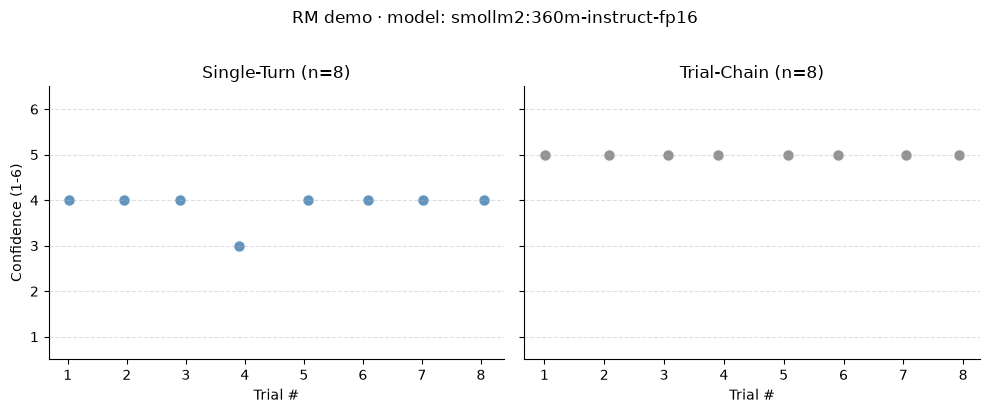

figure → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/csv/rm_demo_figure.png


In [8]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Both ResponseRmStEI (Single-Turn) and AllResponseRMEI (Trial-Chain) surface a
# 'Confidence' field -- nested for Trial-Chain, e.g. {'response': {'Confidence': 5}}
# -- but the regex matches either shape since it just scans the raw string.
_CONF_RE = re.compile(r"Confidence['\"]?\s*[:=]\s*(\d+)")

def load_confidence(csv_path):
    df = pd.read_csv(csv_path)
    df['Confidence'] = df['pred_resp_raw'].apply(
        lambda s: int(_CONF_RE.search(str(s)).group(1)) if _CONF_RE.search(str(s)) else None
    )
    df = df[df['Confidence'].notna()].reset_index(drop=True)
    # Trial number, not raw trial_idx -- Trial-Chain has 4 step-rows per trial,
    # only one of which carries Confidence, so trial_idx alone would misrepresent it.
    x = np.arange(1, len(df) + 1, dtype=float)
    return x, df['Confidence'].values.astype(float)

x_st, y_st = load_confidence(OUT / 'rm_singleturn.csv')
x_tc, y_tc = load_confidence(OUT / 'rm_trialchain.csv')

rng = np.random.default_rng(0)
def jitter(x, s=0.10): return x + rng.uniform(-s, s, size=len(x))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax1.scatter(jitter(x_st), y_st, color='steelblue', s=70, alpha=0.85, edgecolors='white')
ax1.set_title(f'Single-Turn (n={len(x_st)})'); ax1.set_xlabel('Trial #'); ax1.set_ylabel('Confidence (1-6)')
ax2.scatter(jitter(x_tc), y_tc, color='gray', s=70, alpha=0.85, edgecolors='white')
ax2.set_title(f'Trial-Chain (n={len(x_tc)})'); ax2.set_xlabel('Trial #')
# Each panel gets its own x-ticks -- Single-Turn has 8 trials, Trial-Chain only
# 4 (rm_trialchain_demo.json is a smaller demo file), so sharing one combined
# 1-8 range would leave Trial-Chain with empty, misleading space past trial 4.
ax1.set_xticks(range(1, int(x_st.max()) + 1))
ax2.set_xticks(range(1, int(x_tc.max()) + 1))
for ax in (ax1, ax2):
    ax.set_ylim(0.5, 6.5); ax.set_yticks(range(1, 7))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'RM demo · model: {MODEL_NAME}', y=1.02)
plt.tight_layout()
fig.savefig(OUT / 'rm_demo_figure.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'figure → {OUT / "rm_demo_figure.png"}')


## RM accuracy

Source-monitoring accuracy for the two runs above (default `temperature=0`, `nsim=1`, no feedback) — the `Judgment` field compared against each trial's true source (`imagined_*` → `internal`, `perceived_*` → `external`). See [05_rm_task.ipynb](05_rm_task.ipynb) §11 for the fuller SDT/metacognition breakdown of this same accuracy.

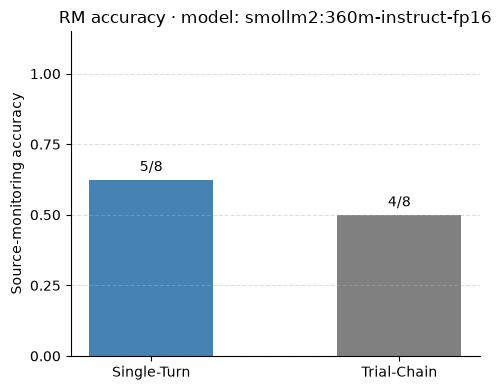

figure → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/csv/rm_accuracy_figure.png
Single-Turn  accuracy: 5/8 = 62%
Trial-Chain  accuracy: 4/8 = 50%


In [9]:
_JUDGE_RE = re.compile(r"Judgment['\"]?\s*[:=]\s*['\"]?(internal|external)")
_TRUE_SOURCE = {'imagined': 'internal', 'perceived': 'external'}

def load_accuracy(csv_path):
    df = pd.read_csv(csv_path)
    df['Judgment'] = df['pred_resp_raw'].apply(
        lambda s: (m := _JUDGE_RE.search(str(s))) and m.group(1)
    )
    df = df[df['Judgment'].notna()]  # Trial-Chain: only 1 of every 4 step-rows carries Judgment
    true_source = df['trcode'].str.split('_').str[0].map(_TRUE_SOURCE)
    correct = (df['Judgment'] == true_source).sum()
    return correct, len(df)

correct_st, n_st = load_accuracy(OUT / 'rm_singleturn.csv')
correct_tc, n_tc = load_accuracy(OUT / 'rm_trialchain.csv')

fig, ax = plt.subplots(figsize=(5, 4))
labels = ['Single-Turn', 'Trial-Chain']
accs = [correct_st / n_st, correct_tc / n_tc]
bars = ax.bar(labels, accs, color=['steelblue', 'gray'], width=0.5)
for bar, acc, correct, n in zip(bars, accs, [correct_st, correct_tc], [n_st, n_tc]):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.03, f'{correct}/{n}', ha='center', fontsize=10)
ax.set_ylim(0, 1.15); ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_ylabel('Source-monitoring accuracy')
ax.set_title(f'RM accuracy · model: {MODEL_NAME}')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(OUT / 'rm_accuracy_figure.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'figure → {OUT / "rm_accuracy_figure.png"}')
print(f'Single-Turn  accuracy: {correct_st}/{n_st} = {correct_st/n_st:.0%}')
print(f'Trial-Chain  accuracy: {correct_tc}/{n_tc} = {correct_tc/n_tc:.0%}')

## Verify install by running the README Quick Start test directly

This calls the test function from `tests/test_readme_quickstart.py` without
invoking pytest — so unrelated tests (like `test_cli.py`) are never touched.


In [10]:
import sys, tempfile, urllib.request, urllib.error
from pathlib import Path

# Make the package's tests/ importable (it has __init__.py, so it works as a module)
PKG_ROOT = Path.cwd().parent
if str(PKG_ROOT) not in sys.path:
    sys.path.insert(0, str(PKG_ROOT))

from tests.test_readme_quickstart import (
    test_readme_quickstart_smoke,
    test_readme_quickstart_live_ollama,
)

# 1. Smoke test: validates ExpCard, default task, parser registry — no API calls
with tempfile.TemporaryDirectory() as tmp:
    test_readme_quickstart_smoke(Path(tmp))
print("PASS — README Quick Start smoke test")

# 2. Live Ollama test: skipped if Ollama isn't reachable on localhost
def _ollama_up(timeout=2.0):
    try:
        with urllib.request.urlopen("http://localhost:11434/api/tags", timeout=timeout) as r:
            return r.status == 200
    except (urllib.error.URLError, TimeoutError, ConnectionError):
        return False

if _ollama_up():
    try:
        with tempfile.TemporaryDirectory() as tmp:
            test_readme_quickstart_live_ollama(Path(tmp))
        print("PASS — README Quick Start live Ollama test")
    except Exception as e:
        print(f"SKIPPED live test: {type(e).__name__}: {str(e)[:140]}")
else:
    print("SKIPPED live test: Ollama not reachable on localhost:11434")


----<PROJECT AND DATA ROOT DIRECTORY>----


	Project root dir: /var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/tmplbzcuehi


	Simulation data root dir: /var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/tmplbzcuehi/readme_quickstart_test/vviq16/ollama_smollm2:360m-instruct-fp16_SingleTurn


----<>----


--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'


...

16it [00:18,  1.14s/it]


2026-08-03 17:58:58.489 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 0


2026-08-03 17:58:58.493 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END


Saved 16 rows → /var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/tmp_k1fntpq/readme_quickstart_test_vviq16_smollm2-360m-instruct-fp16_SingleTurn_20260803_175858.csv
PASS — README Quick Start live Ollama test


## VVIQ-16 mini study (lifted from the unit test)

This block runs the same VVIQ-16 task validated by
`tests/test_readme_quickstart.py::test_readme_quickstart_live_ollama`,
then adds a **Convo** condition for comparison and reproduces the
`09_vviq16_study.ipynb` plot at small scale.


In [11]:
# Mirror of test_readme_quickstart_live_ollama (n=2 instead of 1)
from psychscanner import ExpCardInit, ExpCard, ScannerModel, to_csv
from psychscanner.parsers import DefaultLiteralVivid15

VVIQ_DIR = RUN_DIR / "vviq16"
VVIQ_DIR.mkdir(parents=True, exist_ok=True)
NSIM = 2  # small for a quick local run; bump up for real studies

def vviq_card(memory: str):
    return ExpCardInit(
        model       = MODEL_NAME,
        family      = MODEL_FAMILY,
        parameters  = {"temperature": 0},
        projectname = "vviq16_quickstart",
        proj_dir    = VVIQ_DIR,
        cogtype     = "no",
        nsim        = NSIM,
        memory      = memory,
        parser      = DefaultLiteralVivid15,
    )

scanner_st = ScannerModel(expcard=ExpCard(vviq_card("SingleTurn")))
results_st = scanner_st.run()
print(f"SingleTurn: {len(results_st)} simulations × {len(results_st[0])} trials")


----<PROJECT AND DATA ROOT DIRECTORY>----


	Project root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16


	Simulation data root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_quickstart/vviq16/ollama_smollm2:360m-instruct-fp16_SingleTurn


----<>----


--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'


...

16it [00:23,  1.49s/it]


2026-08-03 17:59:39.613 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 1


2026-08-03 17:59:39.618 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END


SingleTurn: 2 simulations × 16 trials


In [12]:
scanner_cv = ScannerModel(expcard=ExpCard(vviq_card("Convo")))
results_cv = scanner_cv.run()
print(f"Convo:      {len(results_cv)} simulations × {len(results_cv[0])} trials")


----<PROJECT AND DATA ROOT DIRECTORY>----


	Project root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16


	Simulation data root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_quickstart/vviq16/ollama_smollm2:360m-instruct-fp16_Convo


----<>----


--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'


...

16it [00:33,  2.07s/it]


2026-08-03 18:00:44.785 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 1


2026-08-03 18:00:44.791 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END


Convo:      2 simulations × 16 trials


In [13]:
# Export per-condition + combined CSVs
df_st = to_csv(scanner_st, path=VVIQ_DIR / "vviq16_singleturn.csv")
df_cv = to_csv(scanner_cv, path=VVIQ_DIR / "vviq16_convo.csv")
df_all = to_csv([scanner_st, scanner_cv],
                path=VVIQ_DIR / "vviq16_combined.csv",
                combined=True)
print(f"SingleTurn rows: {df_st.shape}")
print(f"Convo      rows: {df_cv.shape}")
print(f"Combined   rows: {df_all.shape}")
df_all.select(["memory", "trcode", "trial_idx", "resp_Vividness"]).head(6)


Saved 32 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_singleturn.csv
Saved 32 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_convo.csv
Saved 64 rows from 2 source(s) → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_combined.csv
SingleTurn rows: (32, 20)
Convo      rows: (32, 20)
Combined   rows: (64, 20)


memory,trcode,trial_idx,resp_Vividness
str,str,i64,i64
"""SingleTurn""","""S1_1""",0,4
"""SingleTurn""","""S1_2""",1,4
"""SingleTurn""","""S1_3""",2,4
"""SingleTurn""","""S1_4""",3,4
"""SingleTurn""","""S2_1""",4,4
"""SingleTurn""","""S2_2""",5,4


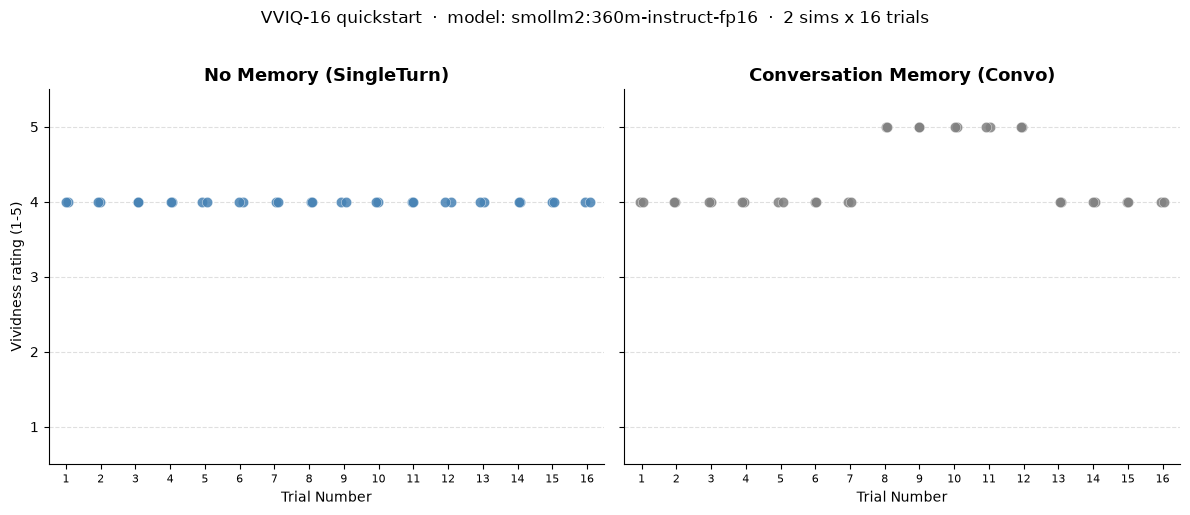

figure -> /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_figure.png
mean Vividness  SingleTurn=4.00  Convo=4.31


In [14]:
# Reproduce the 09_vviq16_study.ipynb scatter (small-n version)
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt

_VIV_RE = re.compile(r"Vividness[^0-9]*(\d+)")

def load_vividness(csv_path):
    df = pd.read_csv(csv_path)
    df["Vividness"] = df["pred_resp_raw"].apply(
        lambda s: int(_VIV_RE.search(str(s)).group(1)) if _VIV_RE.search(str(s)) else None
    )
    return (df["trial_idx"] + 1).values.astype(float), df["Vividness"].values.astype(float)

x_st, y_st = load_vividness(VVIQ_DIR / "vviq16_singleturn.csv")
x_cv, y_cv = load_vividness(VVIQ_DIR / "vviq16_convo.csv")

rng = np.random.default_rng(42)
def jitter(x, s=0.10): return x + rng.uniform(-s, s, size=len(x))

fig, (ax_st, ax_cv) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
ax_st.scatter(jitter(x_st), y_st, color="steelblue", s=55, alpha=0.85,
              linewidths=0.3, edgecolors="white", zorder=3)
ax_st.set_title("No Memory (SingleTurn)", fontsize=13, fontweight="bold")
ax_st.set_xlabel("Trial Number"); ax_st.set_ylabel("Vividness rating (1-5)")

ax_cv.scatter(jitter(x_cv), y_cv, color="gray", s=55, alpha=0.85,
              linewidths=0.3, edgecolors="white", zorder=3)
ax_cv.set_title("Conversation Memory (Convo)", fontsize=13, fontweight="bold")
ax_cv.set_xlabel("Trial Number")

for ax in (ax_st, ax_cv):
    ax.set_xlim(0.5, 16.5); ax.set_xticks(range(1, 17))
    ax.set_xticklabels(range(1, 17), fontsize=8)
    ax.set_ylim(0.5, 5.5); ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"VVIQ-16 quickstart  ·  model: {MODEL_NAME}  ·  {NSIM} sims x 16 trials",
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(VVIQ_DIR / "vviq16_figure.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"figure -> {VVIQ_DIR / 'vviq16_figure.png'}")
m_st = float(np.nanmean(y_st)) if y_st.size else float("nan")
m_cv = float(np.nanmean(y_cv)) if y_cv.size else float("nan")
print(f"mean Vividness  SingleTurn={m_st:.2f}  Convo={m_cv:.2f}")


---
## Further reading

From the psychscanner team, on the two tasks run above:

1. **["Reality Monitoring in Large Language Models: Self-Knowledge That Transforms with Conversation Memory"](https://arxiv.org/abs/2607.23927)** (Ranjan, Sokratous & Odegaard, 2026) — the paradigm behind the RM section above; tests source-monitoring accuracy across six LLMs, including the exact Single-Turn vs Trial-Chain comparison (Fig. 3a/3b) run here.
2. **["Psychological Imagination Networks Show Cross-Population Centrality and Clustering Alignment in Humans That Large Language Models Fail to Replicate"](https://arxiv.org/abs/2510.04391)** (Ranjan & Odegaard, 2025) — network-science analysis of VVIQ ratings across humans and LLMs, directly relevant to the VVIQ-16 mini study run above.

Background on the field:

3. **["Large Language Models as Psychological Simulators: A Methodological Guide"](https://arxiv.org/abs/2506.16702)** (Lin, 2025) — a methodological framework for exactly what this notebook demonstrates: LLMs standing in as simulated participants and computational models of cognition.
4. **["Can Large Language Models Replace Human Subjects? A Large-Scale Replication of Scenario-Based Experiments in Psychology and Management"](https://arxiv.org/abs/2409.00128)** (Cui, Li & Zhou, 2024) — replicates 156 published psychology/management experiments with LLM participants, at a scale far beyond this quickstart's single-trial demo.